Mounted at /content/drive
✅ Trained model loaded successfully from:
/content/drive/MyDrive/Colab Notebooks/R26-IT-012_All_Datasets/Trained_Models/efficientnet_gastric_best.pt
Running predictions on validation data...


Evaluating: 100%|██████████| 11/11 [03:01<00:00, 16.46s/it]



CLASSIFICATION REPORT
                        precision    recall  f1-score   support

      Class 0 (Normal)       0.99      0.99      0.99       200
Class 1 (Inflammation)       0.98      0.98      0.98       124

              accuracy                           0.99       324
             macro avg       0.99      0.99      0.99       324
          weighted avg       0.99      0.99      0.99       324



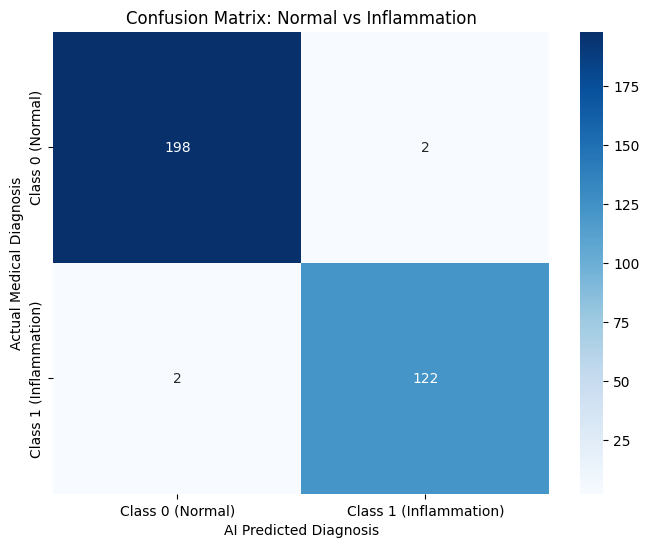

In [1]:
# ==========================================
# 1. IMPORTS & SETUP
# ==========================================
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 2. REBUILD VALIDATION DATASET
# ==========================================
base_dir = '/content/drive/MyDrive/Colab Notebooks/R26-IT-012_All_Datasets/Gastric_Module_Images/labeled-images/upper-gi-tract'
target_classes = {'normal-z-line': 0, 'pylorus': 0, 'erythema': 1, 'esophagitis-a': 1, 'esophagitis-b-d': 1}

image_paths, labels = [], []
for root, dirs, files in os.walk(base_dir):
    folder_name = os.path.basename(root)
    if folder_name in target_classes:
        label = target_classes[folder_name]
        for file in files:
            if file.endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
                labels.append(label)

# We only need the validation split here
_, val_paths, _, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

IMAGE_SIZE = 224 
val_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class GastricDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        image = cv2.cvtColor(cv2.imread(self.image_paths[idx]), cv2.COLOR_BGR2RGB)
        if self.transform: image = self.transform(image=image)['image']
        return image, torch.tensor(self.labels[idx], dtype=torch.long)

val_loader = DataLoader(GastricDataset(val_paths, val_labels, transform=val_transforms), batch_size=32, shuffle=False, num_workers=2)

# ==========================================
# 3. LOAD THE TRAINED MODEL
# ==========================================
MODEL_SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/R26-IT-012_All_Datasets/Trained_Models/efficientnet_gastric_best.pt'

model = timm.create_model('efficientnet_b4', pretrained=False, num_classes=2)
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model = model.to(device)
model.eval()
print(f"✅ Trained model loaded successfully from:\n{MODEL_SAVE_PATH}")

# ==========================================
# 4. RUN PREDICTIONS
# ==========================================
all_preds, all_labels = [], []

print("Running predictions on validation data...")
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ==========================================
# 5. GENERATE METRICS & PLOTS
# ==========================================
target_names = ['Class 0 (Normal)', 'Class 1 (Inflammation)']

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Normal vs Inflammation')
plt.ylabel('Actual Medical Diagnosis')
plt.xlabel('AI Predicted Diagnosis')
plt.show()

In [ ]:
# ==========================================
# 6. MANUAL IMAGE UPLOAD & AI PREDICTION
# ==========================================
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Create the upload button UI
print("👇 Click the 'Upload' button below to test a new medical image:")
uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)

# Create an output area to show the image and results
output_box = widgets.Output()
display(output_box)

# This function runs automatically the moment you select a file
def process_upload(change):
    with output_box:
        clear_output() # Clear previous results if you upload a second image
        
        # Check if file was uploaded
        if not uploader.value:
            return
        
        # Extract the uploaded file data (handles different VS Code widget versions safely)
        try:
            uploaded_file = uploader.value[0] # ipywidgets 8.x
            content = uploaded_file.content
        except KeyError:
            uploaded_filename = list(uploader.value.keys())[0] # ipywidgets 7.x
            content = uploader.value[uploaded_filename]['content']
            
        # 1. Read the image into memory
        image = Image.open(io.BytesIO(content)).convert('RGB')
        image_np = np.array(image)
        
        # 2. Display the uploaded image
        plt.figure(figsize=(4, 4))
        plt.imshow(image_np)
        plt.axis('off')
        plt.title("Your Uploaded Image")
        plt.show()
        
        # 3. Preprocess the image (using the exact same validation rules)
        transformed = val_transforms(image=image_np)
        # Add a "batch" dimension because PyTorch expects [Batch, Channels, Height, Width]
        tensor_image = transformed['image'].unsqueeze(0).to(device) 
        
        # 4. Run the AI Prediction
        model.eval()
        with torch.no_grad():
            raw_outputs = model(tensor_image)
            # Convert raw numbers to percentage probabilities using Softmax
            probabilities = F.softmax(raw_outputs, dim=1)[0] * 100 
            predicted_class = torch.argmax(raw_outputs, dim=1).item()
            
        # 5. Display the Results neatly
        class_names = {0: "Normal (Healthy)", 1: "Inflammation (Gastritis/Esophagitis)"}
        
        print("\n" + "="*45)
        print("🩺 AI DIAGNOSIS RESULTS 🩺")
        print("="*45)
        print(f"➡️ Predicted Diagnosis: {class_names[predicted_class]}")
        print(f"➡️ Confidence Score:    {probabilities[predicted_class]:.2f}%\n")
        
        print("Detailed AI Thoughts:")
        print(f"- Probability of Normal:       {probabilities[0]:.2f}%")
        print(f"- Probability of Inflammation: {probabilities[1]:.2f}%")
        print("="*45)
        
        # Reset the uploader so you can upload another image right away
        uploader.value = () if isinstance(uploader.value, tuple) else {}

# Tell the uploader button to trigger the prediction function
uploader.observe(process_upload, names='value')

👇 Click the 'Upload' button below to test a new medical image:


FileUpload(value={}, accept='image/*', description='Upload')

Output()